                 RAYMER
                   │
                   ▼
        ┌─────────────────────┐
        │  PHYSICS MODEL      │
        │                     │
        │ Requirements        │
        │      ↓              │
        │ Weight Sizing       │
        │      ↓              │
        │ Geometry            │
        │      ↓              │
        │ Aerodynamics        │
        │      ↓              │
        │ Propulsion          │
        │      ↓              │
        │ Performance         │
        │      ↓              │
        │ Mission             │
        └──────────┬──────────┘
                   │
                   ▼
              TBM-X DESIGN
                   │
          ┌────────┴────────┐
          ▼                 ▼
    Benchmark         Data Science
    Validation        / ML / UQ

INPUT
  │
  ├── MTOW guess
  ├── Payload
  ├── Crew
  ├── Mission requirements
  ├── Cruise
  ├── Range
  └── Endurance
        │
        ▼
RAYMER WEIGHT FRACTIONS
        │
        ▼
Mission Fuel Fraction
        │
        ▼
Empty Weight Fraction
        │
        ▼
MTOW
        │
        ▼
ITERATION
        │
        ▼
CONVERGED DESIGN

***Raymer Weight Sizing***

In [ ]:
# ============================================================
# TBM-X — RAYMER AIRCRAFT DESIGN
# PHASE I — WEIGHT SIZING
# ============================================================
#
# Methodology:
#   Daniel P. Raymer
#   Aircraft Design: A Conceptual Approach
#
# Objective:
#   Establish a first-order aircraft weight sizing model
#   for the TBM-X conceptual aircraft.
#
# Important:
#   This model is NOT calibrated to TBM data at this stage.
#   Real aircraft data will be used later for validation..
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TBM-X — Raymer Weight Sizing")
print("Physics model initialized.")

**TBM-X DESIGN REQUIREMENTS**

In [2]:
# ============================================================
# 1. TBM-X DESIGN REQUIREMENTS
# ============================================================

requirements = {

    # --------------------------------------------------------
    # Aircraft category
    # --------------------------------------------------------
    "aircraft_category": "Single Engine Turboprop",

    # --------------------------------------------------------
    # Crew and passengers
    # --------------------------------------------------------
    "crew": 1,
    "passengers": 5,

    # --------------------------------------------------------
    # Mission
    # --------------------------------------------------------
    "range_km": 3000,

    # --------------------------------------------------------
    # Cruise speed
    # --------------------------------------------------------
    "cruise_speed_kt": 300,

    # --------------------------------------------------------
    # Service ceiling
    # --------------------------------------------------------
    "service_ceiling_ft": 31000,

    # --------------------------------------------------------
    # Initial MTOW estimate
    # --------------------------------------------------------
    "mtow_guess_kg": 3400,

    # --------------------------------------------------------
    # Design reserve
    # --------------------------------------------------------
    "fuel_reserve_fraction": 0.10,
}

requirements

{'aircraft_category': 'Single Engine Turboprop',
 'crew': 1,
 'passengers': 5,
 'range_km': 3000,
 'cruise_speed_kt': 300,
 'service_ceiling_ft': 31000,
 'mtow_guess_kg': 3400,
 'fuel_reserve_fraction': 0.1}

**2. UNIT CONVERSION CONSTANTS**

In [3]:
# ============================================================
# 2. UNIT CONVERSION CONSTANTS
# ============================================================

KG_TO_LB = 2.2046226218
LB_TO_KG = 1 / KG_TO_LB

KM_TO_NM = 0.539956803
NM_TO_KM = 1 / KM_TO_NM

KT_TO_MPS = 0.514444
MPS_TO_KT = 1 / KT_TO_MPS

FT_TO_M = 0.3048
M_TO_FT = 1 / FT_TO_M

HP_TO_KW = 0.745699872
KW_TO_HP = 1 / HP_TO_KW

L_TO_GAL = 0.264172052
GAL_TO_L = 1 / L_TO_GAL

**CONVERT DESIGN REQUIREMENTS**

In [4]:
# ============================================================
# 3. CONVERT DESIGN REQUIREMENTS
# ============================================================

mtow_guess_lb = (
    requirements["mtow_guess_kg"] * KG_TO_LB
)

range_nm = (
    requirements["range_km"] * KM_TO_NM
)

cruise_speed_kt = requirements["cruise_speed_kt"]

service_ceiling_ft = requirements["service_ceiling_ft"]

print(f"Initial MTOW guess : {mtow_guess_lb:,.1f} lb")
print(f"Mission range      : {range_nm:,.1f} NM")
print(f"Cruise speed       : {cruise_speed_kt:.1f} kt")
print(f"Service ceiling    : {service_ceiling_ft:,.0f} ft")

Initial MTOW guess : 7,495.7 lb
Mission range      : 1,619.9 NM
Cruise speed       : 300.0 kt
Service ceiling    : 31,000 ft


**4. PAYLOAD ESTIMATION**

In [5]:
# ============================================================
# 4. PAYLOAD ESTIMATION
# ============================================================

crew_weight_lb = requirements["crew"] * 190

passenger_weight_lb = requirements["passengers"] * 190

baggage_weight_lb = (
    (requirements["crew"] + requirements["passengers"])
    * 30
)

payload_lb = (
    crew_weight_lb
    + passenger_weight_lb
    + baggage_weight_lb
)

print(f"Crew weight      : {crew_weight_lb:,.0f} lb")
print(f"Passenger weight : {passenger_weight_lb:,.0f} lb")
print(f"Baggage          : {baggage_weight_lb:,.0f} lb")
print("-" * 40)
print(f"Total payload    : {payload_lb:,.0f} lb")

Crew weight      : 190 lb
Passenger weight : 950 lb
Baggage          : 180 lb
----------------------------------------
Total payload    : 1,320 lb


**MISSION SEGMENTS**

Takeoff
   ↓
Climb
   ↓
Cruise
   ↓
Descent
   ↓
Loiter / Reserve
   ↓
Landing

Wi+1​/Wi​

**"Historical mission fuel fraction / Segment fraction" Approach**

In [7]:
# ============================================================
# 5. RAYMER MISSION SEGMENT WEIGHT FRACTIONS
# ============================================================
#
# Each value represents:
#
#       W_after / W_before
#
# Therefore:
#
#       W_final / W_initial
#
# is obtained by multiplying all segment fractions.
# ============================================================

mission_fractions = {

    "warmup_and_takeoff": 0.970,

    "climb": 0.985,

    "cruise": 0.985,

    "descent": 0.990,

    "loiter_reserve": 0.995,

    "landing": 0.995,
}

mission_fractions

{'warmup_and_takeoff': 0.97,
 'climb': 0.985,
 'cruise': 0.985,
 'descent': 0.99,
 'loiter_reserve': 0.995,
 'landing': 0.995}

**TOTAL MISSION WEIGHT FRACTION**

In [8]:
# ============================================================
# 6. TOTAL MISSION WEIGHT FRACTION
# ============================================================

mission_weight_fraction = np.prod(
    list(mission_fractions.values())
)

fuel_fraction = (
    1 - mission_weight_fraction
)

print(
    f"Mission weight fraction : "
    f"{mission_weight_fraction:.4f}"
)

print(
    f"Mission fuel fraction   : "
    f"{fuel_fraction:.4f}"
)

Mission weight fraction : 0.9224
Mission fuel fraction   : 0.0776


Wf​/W0​

                 MTOW
                   │
        ┌──────────┴──────────┐
        ▼                     ▼
  Empty Weight            Fuel Weight
        │                     │
        ▼                     ▼
   W_empty/W_0          W_fuel/W_0
        │                     │
        └──────────┬──────────┘
                   ▼
                 Payload
                   │
                   ▼
                 MTOW
                   │
                   ▼
               ITERATION

**Empty Weight Fraction**

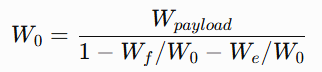

              INITIAL GUESS
                   │
                   ▼
              MTOW₀ = 3400 kg
                   │
                   ▼
        ┌─────────────────────┐
        │  RAYMER CALCULATIONS│
        │                     │
        │  Empty Weight       │
        │  Fuel Weight        │
        │  Payload            │
        └──────────┬──────────┘
                   │
                   ▼
              MTOW₁
                   │
                   ▼
          Compare MTOW₁ vs MTOW₀
                   │
             ┌─────┴─────┐
             │           │
          Error > ε    Error ≤ ε
             │           │
             ▼           ▼
         ITERATE       CONVERGED
             │           │
             └─────┐     │
                   ▼     ▼
                 MTOW₂  TBM-X
                   │
                  ...

Iteration 0    3400 kg

Iteration 1    3528 kg

Iteration 2    3471 kg

Iteration 3    3492 kg

Iteration 4    3484 kg

Iteration 5    3487 kg

Iteration 6    3486 kg
                 ↓
             CONVERGED

| Iteration |     MTOW | Empty Weight | Fuel Weight |           Error |
| --------: | -------: | -----------: | ----------: | --------------: |
|         0 |     3400 |          ... |         ... |               — |
|         1 |     3528 |          ... |         ... |           3.77% |
|         2 |     3471 |          ... |         ... |           1.62% |
|         3 |     3492 |          ... |         ... |           0.61% |
|         4 |     3484 |          ... |         ... |           0.23% |
|         5 |     3487 |          ... |         ... |           0.09% |
|         6 | **3486** |          ... |         ... | **< tolerance** |


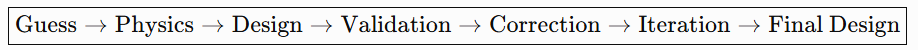

**EMPTY WEIGHT FRACTION MODEL**

In [9]:
# ============================================================
# 7. EMPTY WEIGHT FRACTION MODEL
# ============================================================
#
# IMPORTANT:
# Bu fonksiyon şimdilik loop altyapısını kurmak içindir.
#
# Raymer'a ait kesin regression coefficients burada
# daha sonra ayrı olarak doğrulanacaktır.
#
# Böylece weight sizing loop'u ile
# empty weight correlation birbirinden ayrılmış olur.
# ============================================================

def estimate_empty_weight_fraction(
    mtow_lb,
    A=2.36,
    C=-0.18,
    K_vs=1.00
):
    """
    Initial empty weight fraction estimation.

    Parameters
    ----------
    mtow_lb : float
        Current MTOW estimate [lb]

    A : float
        Empty weight regression coefficient

    C : float
        Empty weight regression exponent

    K_vs : float
        Correction factor

    Returns
    -------
    float
        Estimated empty weight fraction [-]
    """

    empty_weight_fraction = (
        A
        * (mtow_lb ** C)
        * K_vs
    )

    return empty_weight_fraction

**Test**

In [10]:
test_empty_fraction = estimate_empty_weight_fraction(
    mtow_guess_lb
)

print(
    "Initial empty weight fraction: "
    f"{test_empty_fraction:.4f}"
)

Initial empty weight fraction: 0.4736


**FUEL RESERVE**

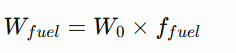

In [11]:
# ============================================================
# 8. FUEL RESERVE
# ============================================================

mission_fuel_fraction = fuel_fraction

fuel_reserve_fraction = requirements[
    "fuel_reserve_fraction"
]

total_fuel_fraction = (
    mission_fuel_fraction
    * (1 + fuel_reserve_fraction)
)

print(
    f"Mission fuel fraction : "
    f"{mission_fuel_fraction:.4f}"
)

print(
    f"Fuel reserve factor   : "
    f"{fuel_reserve_fraction:.4f}"
)

print(
    f"Total fuel fraction   : "
    f"{total_fuel_fraction:.4f}"
)

Mission fuel fraction : 0.0776
Fuel reserve factor   : 0.1000
Total fuel fraction   : 0.0853


**MTOW sizing**

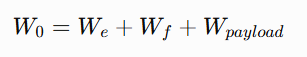

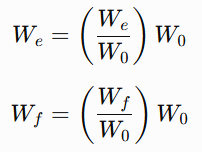

So;

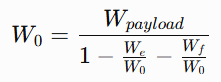

In [12]:
# ============================================================
# 9. MTOW SIZING EQUATION
# ============================================================

def calculate_mtow(
    payload_weight_lb,
    empty_weight_fraction,
    fuel_fraction
):
    """
    Calculate a new MTOW estimate.

    Parameters
    ----------
    payload_weight_lb : float
        Payload weight [lb]

    empty_weight_fraction : float
        We / W0 [-]

    fuel_fraction : float
        Wf / W0 [-]

    Returns
    -------
    float
        New MTOW estimate [lb]
    """

    denominator = (
        1
        - empty_weight_fraction
        - fuel_fraction
    )

    if denominator <= 0:
        raise ValueError(
            "Invalid weight fractions: "
            "empty weight fraction + fuel fraction >= 1."
        )

    mtow_new_lb = (
        payload_weight_lb
        / denominator
    )

    return mtow_new_lb

**SINGLE ITERATION TEST**

In [14]:
# ============================================================
# 10. SINGLE ITERATION TEST
# ============================================================

current_mtow_lb = mtow_guess_lb

empty_fraction = estimate_empty_weight_fraction(
    current_mtow_lb
)

new_mtow_lb = calculate_mtow(
    payload_weight_lb=payload_lb,
    empty_weight_fraction=empty_fraction,
    fuel_fraction=total_fuel_fraction
)

print(
    f"Current MTOW : "
    f"{current_mtow_lb:,.1f} lb"
)

print(
    f"New MTOW     : "
    f"{new_mtow_lb:,.1f} lb"
)

print(
    f"Difference   : "
    f"{new_mtow_lb - current_mtow_lb:,.1f} lb"
)

Current MTOW : 7,495.7 lb
New MTOW     : 2,993.1 lb
Difference   : -4,502.6 lb


**CONVERGENCE SETTINGS**

In [15]:
# ============================================================
# 11. CONVERGENCE SETTINGS
# ============================================================

MAX_ITERATIONS = 100

TOLERANCE = 1e-4

print(
    f"Maximum iterations : {MAX_ITERATIONS}"
)

print(
    f"Relative tolerance : {TOLERANCE}"
)

Maximum iterations : 100
Relative tolerance : 0.0001


Relative Error: 

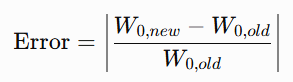

**RAYMER MTOW ITERATION LOOP**

In [16]:
# ============================================================
# 12. RAYMER MTOW ITERATION LOOP
# ============================================================

mtow_current_lb = mtow_guess_lb

iteration_history = []

converged = False


for iteration in range(
    1,
    MAX_ITERATIONS + 1
):

    # --------------------------------------------------------
    # Step 1
    # Estimate empty weight fraction
    # --------------------------------------------------------

    empty_fraction = (
        estimate_empty_weight_fraction(
            mtow_current_lb
        )
    )


    # --------------------------------------------------------
    # Step 2
    # Calculate new MTOW
    # --------------------------------------------------------

    mtow_new_lb = calculate_mtow(
        payload_weight_lb=payload_lb,
        empty_weight_fraction=empty_fraction,
        fuel_fraction=total_fuel_fraction
    )


    # --------------------------------------------------------
    # Step 3
    # Calculate relative error
    # --------------------------------------------------------

    relative_error = abs(
        (
            mtow_new_lb
            - mtow_current_lb
        )
        / mtow_current_lb
    )


    # --------------------------------------------------------
    # Step 4
    # Save iteration history
    # --------------------------------------------------------

    iteration_history.append(
        {
            "iteration": iteration,
            "mtow_current_lb": mtow_current_lb,
            "empty_weight_fraction": empty_fraction,
            "fuel_fraction": total_fuel_fraction,
            "mtow_new_lb": mtow_new_lb,
            "relative_error": relative_error
        }
    )


    # --------------------------------------------------------
    # Step 5
    # Check convergence
    # --------------------------------------------------------

    if relative_error < TOLERANCE:

        converged = True

        mtow_current_lb = mtow_new_lb

        break


    # --------------------------------------------------------
    # Step 6
    # Update MTOW
    # --------------------------------------------------------

    mtow_current_lb = mtow_new_lb

MTOW guess
    ↓
Empty Weight Fraction
    ↓
New MTOW
    ↓
Error
    ↓
Converged?
    │
 ┌──┴──┐
No     Yes
│       │
▼       ▼
Repeat  Stop

In [17]:
# ============================================================
# 13. ITERATION HISTORY
# ============================================================

df_iterations = pd.DataFrame(
    iteration_history
)

df_iterations

,iteration,mtow_current_lb,empty_weight_fraction,fuel_fraction,mtow_new_lb,relative_error
0,1,7495.716914,0.473637,0.085345,2993.077773,0.600695
1,2,2993.077773,0.558741,0.085345,3708.768056,0.239115
2,3,3708.768056,0.537589,0.085345,3500.720255,0.056096
3,4,3500.720255,0.543205,0.085345,3553.643719,0.015118
4,5,3553.643719,0.541740,0.085345,3539.681883,0.003929
5,6,3539.681883,0.542124,0.085345,3543.330617,0.001031
6,7,3543.330617,0.542023,0.085345,3542.374707,0.000270
7,8,3542.374707,0.542050,0.085345,3542.624978,0.000071


**FINAL RESULTS**

In [18]:
# ============================================================
# 14. FINAL RESULTS
# ============================================================

final_mtow_lb = mtow_current_lb

final_mtow_kg = (
    final_mtow_lb
    * LB_TO_KG
)

final_empty_fraction = (
    estimate_empty_weight_fraction(
        final_mtow_lb
    )
)

final_empty_weight_lb = (
    final_mtow_lb
    * final_empty_fraction
)

final_fuel_weight_lb = (
    final_mtow_lb
    * total_fuel_fraction
)

print("=" * 60)
print("TBM-X — RAYMER WEIGHT SIZING RESULT")
print("=" * 60)

print(
    f"Converged          : {converged}"
)

print(
    f"Iterations         : {len(df_iterations)}"
)

print()

print(
    f"Final MTOW         : "
    f"{final_mtow_lb:,.1f} lb"
)

print(
    f"Final MTOW         : "
    f"{final_mtow_kg:,.1f} kg"
)

print()

print(
    f"Empty Weight       : "
    f"{final_empty_weight_lb:,.1f} lb"
)

print(
    f"Empty Fraction     : "
    f"{final_empty_fraction:.4f}"
)

print()

print(
    f"Fuel Weight        : "
    f"{final_fuel_weight_lb:,.1f} lb"
)

print(
    f"Fuel Fraction      : "
    f"{total_fuel_fraction:.4f}"
)

print()

print(
    f"Payload            : "
    f"{payload_lb:,.1f} lb"
)

TBM-X — RAYMER WEIGHT SIZING RESULT
Converged          : True
Iterations         : 8

Final MTOW         : 3,542.6 lb
Final MTOW         : 1,606.9 kg

Empty Weight       : 1,920.3 lb
Empty Fraction     : 0.5420

Fuel Weight        : 302.3 lb
Fuel Fraction      : 0.0853

Payload            : 1,320.0 lb


**WEIGHT BREAKDOWN CHECK**

In [19]:
# ============================================================
# 15. WEIGHT BREAKDOWN CHECK
# ============================================================

weight_breakdown_lb = (
    final_empty_weight_lb
    + final_fuel_weight_lb
    + payload_lb
)

weight_balance_error_lb = (
    final_mtow_lb
    - weight_breakdown_lb
)

print(
    f"Calculated MTOW : "
    f"{final_mtow_lb:,.2f} lb"
)

print(
    f"Weight breakdown: "
    f"{weight_breakdown_lb:,.2f} lb"
)

print(
    f"Balance error   : "
    f"{weight_balance_error_lb:.6f} lb"
)

Calculated MTOW : 3,542.62 lb
Weight breakdown: 3,542.60 lb
Balance error   : 0.024419 lb


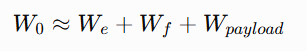

**MTOW CONVERGENCE**

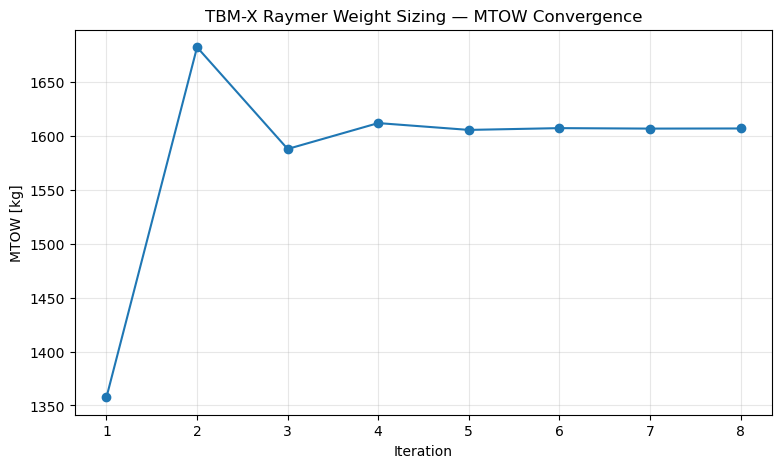

In [20]:
# ============================================================
# 16. MTOW CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    df_iterations["iteration"],
    df_iterations["mtow_new_lb"]
    * LB_TO_KG,
    marker="o"
)

plt.xlabel("Iteration")

plt.ylabel("MTOW [kg]")

plt.title(
    "TBM-X Raymer Weight Sizing — MTOW Convergence"
)

plt.grid(alpha=0.3)

plt.show()

**CONVERGENCE ERROR**

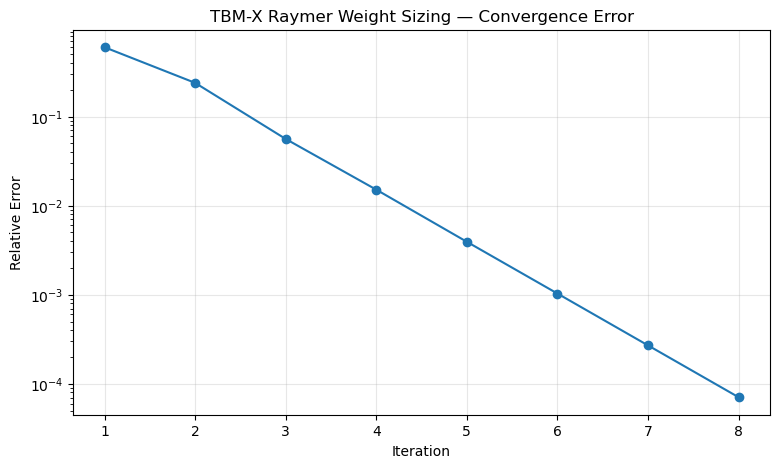

In [21]:
# ============================================================
# 17. CONVERGENCE ERROR
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    df_iterations["iteration"],
    df_iterations["relative_error"],
    marker="o"
)

plt.yscale("log")

plt.xlabel("Iteration")

plt.ylabel("Relative Error")

plt.title(
    "TBM-X Raymer Weight Sizing — Convergence Error"
)

plt.grid(alpha=0.3)

plt.show()